In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/netflix-inc/netflix-prize-data/combined_data_3.txt
/kaggle/input/datasets/netflix-inc/netflix-prize-data/movie_titles.csv
/kaggle/input/datasets/netflix-inc/netflix-prize-data/combined_data_4.txt
/kaggle/input/datasets/netflix-inc/netflix-prize-data/combined_data_1.txt
/kaggle/input/datasets/netflix-inc/netflix-prize-data/README
/kaggle/input/datasets/netflix-inc/netflix-prize-data/probe.txt
/kaggle/input/datasets/netflix-inc/netflix-prize-data/combined_data_2.txt
/kaggle/input/datasets/netflix-inc/netflix-prize-data/qualifying.txt


In [2]:
import pandas as pd
import numpy as np
import math 
import torch 
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.nn.functional as F
from math import log2

In [3]:
import torch
print(torch.cuda.is_available())

True


In [4]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [5]:
def load_netflix_data(file_path):
    data = []
    with open(file_path, 'r') as f:
        movie_id = None
        for line in f:
            line = line.strip()
            if not line:  # пропускаем пустые строки
                continue
            if line.endswith(':'):
                movie_id = int(line[:-1])  # запоминаем ID фильма
            else:
                parts = line.split(',')
                if len(parts) >= 3:
                    customer = int(parts[0])
                    rating = float(parts[1])
                    date = parts[2]
                    data.append([movie_id, customer, rating, date])
    return pd.DataFrame(data, columns=['MovieID', 'CustomerID', 'Rating', 'Date'])
df1 = load_netflix_data('/kaggle/input/datasets/netflix-inc/netflix-prize-data/combined_data_1.txt')
df2 = load_netflix_data('/kaggle/input/datasets/netflix-inc/netflix-prize-data/combined_data_2.txt')
df3 = load_netflix_data('/kaggle/input/datasets/netflix-inc/netflix-prize-data/combined_data_3.txt')
df4 = load_netflix_data('/kaggle/input/datasets/netflix-inc/netflix-prize-data/combined_data_4.txt')

In [6]:
df1.head()

,MovieID,CustomerID,Rating,Date
0,1,1488844,3.0,2005-09-06
1,1,822109,5.0,2005-05-13
2,1,885013,4.0,2005-10-19
3,1,30878,4.0,2005-12-26
4,1,823519,3.0,2004-05-03


In [7]:
movies_title = pd.read_csv('/kaggle/input/datasets/netflix-inc/netflix-prize-data/movie_titles.csv',names = ['MovieID','Year','Title'],header = None, encoding = 'iso-8859-1',on_bad_lines = 'skip')

In [8]:
movies_title[movies_title['Year'].isna()]

,MovieID,Year,Title
4305,4388,NaN,Ancient Civilizations: Rome and Pompeii
4704,4794,NaN,Ancient Civilizations: Land of the Pharaohs
7114,7241,NaN,Ancient Civilizations: Athens and Greece
10590,10782,NaN,Roti Kapada Aur Makaan
15621,15918,NaN,Hote Hote Pyaar Ho Gaya
16359,16678,NaN,Jimmy Hollywood
17331,17667,NaN,Eros Dance Dhamaka


In [9]:
years = [2001,2001,2002,1974,1999,1994,1995]

In [10]:
rows_with_nan = movies_title[movies_title['Year'].isna()].index
print(rows_with_nan)

Index([4305, 4704, 7114, 10590, 15621, 16359, 17331], dtype='int64')


In [11]:
movies_title.loc[rows_with_nan, 'Year'] = years

In [12]:
movies_title.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17434 entries, 0 to 17433
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   MovieID  17434 non-null  int64  
 1   Year     17434 non-null  float64
 2   Title    17434 non-null  object 
dtypes: float64(1), int64(1), object(1)
memory usage: 408.7+ KB


In [13]:
print(movies_title['MovieID'].nunique())

17434


In [14]:
print(df1['MovieID'].nunique())
print(df2['MovieID'].nunique())
print(df3['MovieID'].nunique())
print(df4['MovieID'].nunique())

4499
4711
4157
4403


In [15]:
print(df1['CustomerID'].nunique())
print(df2['CustomerID'].nunique())
print(df3['CustomerID'].nunique())
print(df4['CustomerID'].nunique())

470758
474062
474662
475601


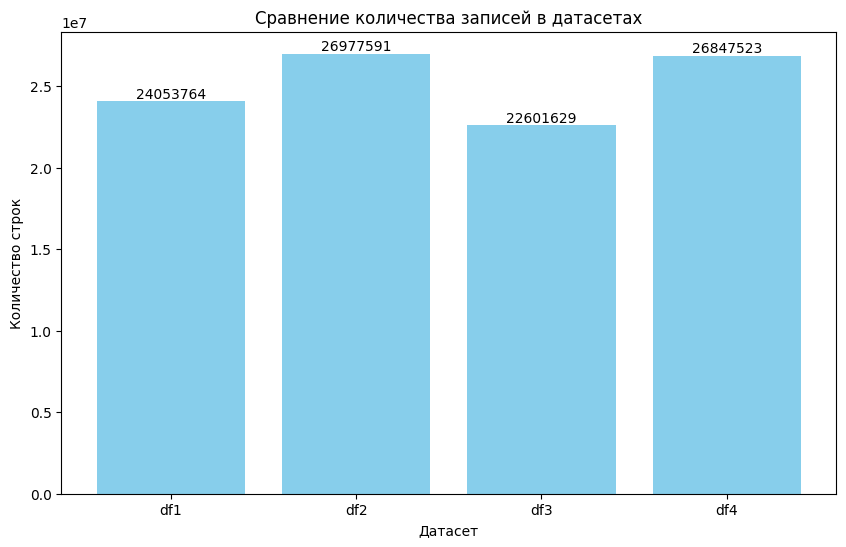

In [16]:
names = ['df1','df2','df3','df4']
datasets = [df1,df2,df3,df4]
total_rows = [i.shape[0] for i in datasets]
plt.figure(figsize = (10,6))
bars = plt.bar(names, total_rows, color='skyblue')
plt.title('Сравнение количества записей в датасетах')
plt.xlabel('Датасет')
plt.ylabel('Количество строк')
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.5,
             f'{int(height)}', ha='center', va='bottom')
plt.show()

Как мы видим самое большое количество оценок во втором датасете, по нему можно будет проводить обучение и делать оценки касательно эффективности алгоритмов, чтобы не проводить обучение на всём датасете их миллиона строк

In [17]:
all_customers = pd.concat([
    df1['CustomerID'],
    df2['CustomerID'],
    df3['CustomerID'],
    df4['CustomerID']
])

unique_count = all_customers.nunique()
print(f"Всего уникальных CustomerID: {unique_count}")

Всего уникальных CustomerID: 480189


Проведём обучение через SVD++ на втором датасете,так как он вмещает в себя наибольшее количество оценок, затем сделаю факторизационную матрицу с items_features: Год выпуска фильма, векторное представление названия фильма, user_features: средний год проставления оценки

In [18]:
df2['Year'] = df2['Date'].str.split('-').str[0]
unique_years = df2['Year'].unique()
count_unique = df2['Year'].nunique()

In [19]:
print(unique_years)
print(count_unique)

['2005' '2004' '2003' '2001' '2002' '2000' '1999']
7


Временной интервал, который захватывает df2 - 1999 - 2005 год

In [20]:
df2['Year'] = df2['Year'].astype(int)

In [21]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26977591 entries, 0 to 26977590
Data columns (total 5 columns):
 #   Column      Dtype  
---  ------      -----  
 0   MovieID     int64  
 1   CustomerID  int64  
 2   Rating      float64
 3   Date        object 
 4   Year        int64  
dtypes: float64(1), int64(3), object(1)
memory usage: 1.0+ GB


Извлечём латентные признаки с помощью SVD++ из библиотеки suprise, также посмотрим какие результаты по метрикам будут на тестовых данных у этой модели, так как SVD++ работает с тройкой - MovieID, CustomerID, Rating не будем добавлять фактор времени в нашу модель

In [22]:
from surprise import Dataset, Reader, SVDpp
from surprise.model_selection import train_test_split
from surprise import accuracy
import time

In [23]:
def evaluate_model(df, model_params=None):
    reader = Reader(rating_scale=(1, 5))
    data = Dataset.load_from_df(df[['CustomerID', 'MovieID', 'Rating']], reader)
    trainset, testset = train_test_split(data, test_size=0.2, random_state=42)
    if model_params is None:
        model_params = {
            'n_factors': 20,
            'n_epochs': 10,
            'lr_all': 0.007,
            'reg_all': 0.02,
            'cache_ratings': True,
            'verbose': True
        }
    algo = SVDpp(**model_params)
    start = time.time()
    algo.fit(trainset)
    end = time.time()
    training_time = end - start
    predictions = algo.test(testset)
    rmse = accuracy.rmse(predictions)
    mae = accuracy.mae(predictions)
    return rmse, mae, training_time, predictions

In [24]:
# NDCG = DCG@k/IDCG@k,DCG@k = sum(rel(i)/log(i+1))-реелевантность по предсказанной оценке, IDCG@k = sum(rel(i)/log(i+1)) - релевантность по истинной оценке
def ndcg_at_k(preds, k = 10,threshold = 4):
    user_preds = {}
    for pred in preds:
        uid = pred.uid
        if uid not in user_preds:
            user_preds[uid] = []
        user_preds[uid].append(pred)
    ndcg_scores = []
    for uid,pred_list in user_preds.items():
        if not pred_list:
            continue
#r_ui - истинная оценка фильма,которую поставил пользователь, rel_i - релевантность элемента на позиции i, est - предсказанный рейтинг
        #Сортируем по предсказанной оценке
        sorted_by_est = sorted(pred_list, key=lambda x: x.est, reverse=True)
        top_k_est = sorted_by_est[:k]
        rel = [1 if p.r_ui >= threshold else 0 for p in top_k_est]
        dcg = 0.0
        for i, rel_i in enumerate(rel, start=1):
            dcg += rel_i / log2(i + 1)
#Сортируем фильмы по истинной оценке
        sorted_by_true = sorted(pred_list, key=lambda x: x.r_ui, reverse=True)
        top_k_true = sorted_by_true[:k]
        ideal_rel = [1 if p.r_ui >= threshold else 0 for p in top_k_true]      
        idcg = 0.0
        for i, rel_i in enumerate(ideal_rel, start=1):
            idcg += rel_i / log2(i + 1)
        if idcg == 0:
            ndcg = 0.0
        else:
            ndcg = dcg / idcg
        ndcg_scores.append(ndcg)
    return np.mean(ndcg_scores) if ndcg_scores else 0.0

In [25]:
#расчёт Precision10@k precision = relevant/k
def precision_at_k(preds, k=10, threshold=4):
    user_preds = {}
    for pred in preds:
        uid = pred.uid
        if uid not in user_preds:
            user_preds[uid] = []
        user_preds[uid].append(pred)    
    precision_scores = []
    for uid, pred_list in user_preds.items():
        if not pred_list:
            continue
        sorted_preds = sorted(pred_list, key=lambda x: x.est, reverse=True)
        top_k = sorted_preds[:k]
        relevant = sum(1 for p in top_k if p.r_ui >= threshold)
        precision = relevant / k
        precision_scores.append(precision)
    return np.mean(precision_scores) if precision_scores else 0.0

In [26]:
rmse_SVDpp, mae_SVDpp, train_time_SVDpp, preds = evaluate_model(df2)
prec_SVDpp = precision_at_k(preds, k=10)
ndcg_SVDpp = ndcg_at_k(preds, k=10)
print(f"RMSE = {rmse_SVDpp:.2f}, MAE = {mae_SVDpp:.2f}, Precision@10 = {prec_SVDpp:.4f}, NDCG@10 = {ndcg_SVDpp:.4f},train_time = {train_time_SVDpp:.2f}")
results = []
results.append({
    'Model': 'SVDpp',
    'RMSE': rmse_SVDpp,
    'Precision10@k': prec_SVDpp,
    'ncdg': ndcg_SVDpp,
    'train_time': train_time_SVDpp
})
ispitaniya_results = pd.DataFrame(results)

 processing epoch 0
 processing epoch 1
 processing epoch 2
 processing epoch 3
 processing epoch 4
 processing epoch 5
 processing epoch 6
 processing epoch 7
 processing epoch 8
 processing epoch 9
RMSE: 0.9363
MAE:  0.7171
RMSE = 0.94, MAE = 0.72, Precision@10 = 0.4158, NDCG@10 = 0.8077,train_time = 1519.48


Precision@10 = 0.42 обозначает, что пользователь взаимодействует только с 4 из 10 рекомендованных фильмов, NDCG = 0.81 показывает, что 8 из 10 фильмов были правильно отрнжированы по своей релевантности

Сделаем кастомную реализацию матричной факторизацией с учетом временного смещения, посмотрим насколько сильно вырастят метрики качества, для этого проведём feature engineering и добавим в модель фактор, нормализирующий время, вычтем из текущей даты каждой оценки минимальную дату оценки пользователяя и разделим её на разницу между максимальной датой оценки и минимальной, проведём тренировку на ранних оценках и протестируем на поздних, чтобы сделать оценку метрик более честным

In [27]:
from torch.utils.data import Dataset, DataLoader
ratings_df = df2
n_users = df2['CustomerID'].nunique()
n_movies = df2['MovieID'].nunique()
n_ratings = len(df2)
user2idx = {uid: i for i, uid in enumerate(ratings_df['CustomerID'].unique())}
movie2idx = {mid: i for i, mid in enumerate(ratings_df['MovieID'].unique())}
n_users = len(user2idx)
n_movies = len(movie2idx)
ratings_df['u_idx'] = ratings_df['CustomerID'].map(user2idx)
ratings_df['m_idx'] = ratings_df['MovieID'].map(movie2idx)
ratings_df['date_parsed'] = pd.to_datetime(ratings_df['Date'])
min_date = ratings_df['date_parsed'].min()
max_date = ratings_df['date_parsed'].max()
ratings_df['days_norm'] = (
    (ratings_df['date_parsed'] - min_date).dt.days
    / (max_date - min_date).days
)
ratings_df = ratings_df.sort_values('date_parsed')
split_idx = int(len(ratings_df) * 0.8)
train_df = ratings_df.iloc[:split_idx]
test_df = ratings_df.iloc[split_idx:]

Преобразуем в целочисленные тензоры - customerid и movieid, в вещественные тензоры - нормированную дату и рейтинг, сделаем train и test датасеты с батчами по 8192 объекта

In [28]:
class RatingsDataset(Dataset):
    def __init__(self, df):
        self.u = torch.LongTensor(df['u_idx'].values)
        self.m = torch.LongTensor(df['m_idx'].values)
        self.r = torch.FloatTensor(df['Rating'].values)
        self.d = torch.FloatTensor(df['days_norm'].values)
    def __len__(self):
        return len(self.r)
    def __getitem__(self, idx):
        return self.u[idx], self.m[idx], self.r[idx], self.d[idx]
train_ds = RatingsDataset(train_df)
test_ds  = RatingsDataset(test_df)
train_loader = DataLoader(train_ds, batch_size=8192, shuffle=True)
test_loader  = DataLoader(test_ds,  batch_size=8192)

Создадим эмбеддинги для для данных, инициализируем веса, смещения, схожесть пользователя и фильма найдем через скалярное произведение векторов пользователя и фильма

In [29]:
class TemporalMF(nn.Module):
    def __init__(self, n_users, n_movies, n_factors=20, dropout=0.2):
        super().__init__()
        self.user_embedding = nn.Embedding(n_users, n_factors)
        self.movie_embedding = nn.Embedding(n_movies, n_factors)
        nn.init.normal_(self.user_embedding.weight, 0, 0.1)
        nn.init.normal_(self.movie_embedding.weight, 0, 0.1)
        self.user_bias = nn.Embedding(n_users, 1)
        self.movie_bias = nn.Embedding(n_movies, 1)
        self.global_bias = nn.Parameter(torch.tensor(3.0))
        self.time_bias = nn.Linear(1, 1)
        self.dropout = nn.Dropout(dropout)
    def forward(self, u, m, d):
        p_u = self.dropout(self.user_embedding(u))
        q_i = self.dropout(self.movie_embedding(m))
        interaction = (p_u * q_i).sum(dim=1)
        b_u = self.user_bias(u).squeeze(1)
        b_i = self.movie_bias(m).squeeze(1)
        b_t = self.time_bias(d.unsqueeze(1)).squeeze(1)
        pred = self.global_bias + b_u + b_i + interaction + b_t
        return torch.clamp(pred, 1.0, 5.0)

для оптимизатора используем алгоритм Адам

In [31]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = TemporalMF(n_users, n_movies, n_factors=20, dropout=0.2).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.005, weight_decay=1e-5)
criterion = nn.MSELoss()
train_times = []
for epoch in range(10):
    model.train()
    total_loss = 0
    epoch_start = time.time()
    for u, m, r, d in train_loader:
        u, m, r, d = u.to(device, non_blocking = True), m.to(device,non_blocking = True), r.to(device,non_blocking = True), d.to(device,non_blocking = True)
        optimizer.zero_grad()
        pred = model(u, m, d)
        loss = criterion(pred, r)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(r)
    epoch_time = time.time() - epoch_start
    train_times.append(epoch_time)
    # Валидация
    model.eval()
    test_loss = 0
    with torch.no_grad():
        for u, m, r, d in test_loader:
            u, m, r, d = u.to(device), m.to(device), r.to(device), d.to(device)
            pred = model(u, m, d)
            test_loss += criterion(pred, r).item() * len(r)
    train_rmse = np.sqrt(total_loss / len(train_ds))
    test_rmse  = np.sqrt(test_loss / len(test_ds))
    total_train_time = sum(train_times)
    print(f"Epoch {epoch+1:2d} | Train RMSE: {train_rmse:.4f} | Test RMSE: {test_rmse:.4f} | Время на одну эпоху: {epoch_time:.2f}")
print(f"Общее время: {total_train_time:.1f}s")

Epoch  1 | Train RMSE: 1.0051 | Test RMSE: 1.0161 | Время на одну эпоху: 391.15
Epoch  2 | Train RMSE: 0.9177 | Test RMSE: 1.0141 | Время на одну эпоху: 393.95
Epoch  3 | Train RMSE: 0.9157 | Test RMSE: 1.0153 | Время на одну эпоху: 389.93
Epoch  4 | Train RMSE: 0.9153 | Test RMSE: 1.0141 | Время на одну эпоху: 371.36
Epoch  5 | Train RMSE: 0.9151 | Test RMSE: 1.0144 | Время на одну эпоху: 367.59
Epoch  6 | Train RMSE: 0.9150 | Test RMSE: 1.0148 | Время на одну эпоху: 364.79
Epoch  7 | Train RMSE: 0.9149 | Test RMSE: 1.0140 | Время на одну эпоху: 370.44
Epoch  8 | Train RMSE: 0.9149 | Test RMSE: 1.0149 | Время на одну эпоху: 369.99
Epoch  9 | Train RMSE: 0.9148 | Test RMSE: 1.0145 | Время на одну эпоху: 378.21
Epoch 10 | Train RMSE: 0.9149 | Test RMSE: 1.0137 | Время на одну эпоху: 371.37
Общее время: 3768.8s


In [32]:
def precision_at_k(user_preds, k=10, relevance_threshold=4):
    precisions = []
    for user_idx, items in user_preds.items():
        if len(items) < k:
            continue  
        items_sorted = sorted(items, key=lambda x: x[1], reverse=True)
        top_k = items_sorted[:k]
        relevant_count = sum(1 for _, _, real_r in top_k if real_r >= relevance_threshold)
        precisions.append(relevant_count / k)
    return np.mean(precisions)

In [33]:
def ndcg_at_k(user_preds, k=10, relevance_threshold=4):
    ndcgs = []
    for user_idx, items in user_preds.items():
        if len(items) < k:
            continue
        items_sorted = sorted(items, key=lambda x: x[1], reverse=True)
        top_k = items_sorted[:k]
        dcg = 0.0
        for position, (_, _, real_r) in enumerate(top_k):
            rel = 1.0 if real_r >= relevance_threshold else 0.0
            dcg += rel / np.log2(position + 2) 
        ideal_items = sorted(items, key=lambda x: x[2], reverse=True)
        ideal_top_k = ideal_items[:k]
        idcg = 0.0
        for position, (_, _, real_r) in enumerate(ideal_top_k):
            rel = 1.0 if real_r >= relevance_threshold else 0.0
            idcg += rel / np.log2(position + 2)
        if idcg == 0:
            continue  
        ndcgs.append(dcg / idcg)
    return np.mean(ndcgs)

Вернем данные обратно на CPU из test_loader, чтобы посчитать метрики Precision10@k и NDCG

In [34]:
from collections import defaultdict
def collect_predictions(model, test_loader, device):
    model.eval()
    user_preds = defaultdict(list)
    with torch.no_grad():
        for u, m, r, d in test_loader:
            u, m, r, d = u.to(device), m.to(device), r.to(device), d.to(device)
            preds = model(u, m, d)
            u_cpu = u.cpu().numpy()
            m_cpu = m.cpu().numpy()
            r_cpu = r.cpu().numpy()
            p_cpu = preds.cpu().numpy()
            for i in range(len(u_cpu)):
                user_preds[u_cpu[i]].append((m_cpu[i], p_cpu[i], r_cpu[i]))
    return user_preds

In [35]:
metrics_start = time.time()
user_preds = collect_predictions(model, test_loader, device)
precision_10 = precision_at_k(user_preds, k=10, relevance_threshold=4)
ndcg_10 = ndcg_at_k(user_preds, k=10, relevance_threshold=4)
metrics_time = time.time() - metrics_start
print(f"Precision@10: {precision_10:.4f}")
print(f"NDCG@10:{ndcg_10:.4f}")
print(f"Время подсчёта метрик: {metrics_time:.1f}s")

Precision@10: 0.7079
NDCG@10:0.8066
Время подсчёта метрик: 105.0s


Как мы видим модель намного лучше предлагает объекты пользователю, которые впоследствие становятся релевантными(Precicsion10@k = 0.71 vs Pr = 0.4),по качеству ранжирования она сопоставима с SVDpp (NDCG = 0.81), но по времени обучения модель SVDpp обучается быстрее

In [46]:
new_row = pd.DataFrame({
    'Model': [model],
    'RMSE': [test_rmse],
    'Precision10@k': [precision_10],
    'ncdg': [ndcg_10],
    'train_time': [total_train_time]
}, index=['TemporalMF']) 
ispitaniya_results = pd.concat([ispitaniya_results, new_row], ignore_index = True)

Сравним результаты матричной факторизации с кастомной матричной факторизацией с временным смещением и MLP-based рекомендациями

In [37]:
ratings_df = df2
n_users = df2['CustomerID'].nunique()
n_movies = df2['MovieID'].nunique()
n_ratings = len(df2)
user2idx = {uid: i for i, uid in enumerate(ratings_df['CustomerID'].unique())}
movie2idx = {mid: i for i, mid in enumerate(ratings_df['MovieID'].unique())}
n_users = len(user2idx)
n_movies = len(movie2idx)
ratings_df['u_idx'] = ratings_df['CustomerID'].map(user2idx)
ratings_df['m_idx'] = ratings_df['MovieID'].map(movie2idx)
ratings_df['date_parsed'] = pd.to_datetime(ratings_df['Date'])
min_date = ratings_df['date_parsed'].min()
max_date = ratings_df['date_parsed'].max()
ratings_df['days_norm'] = (
    (ratings_df['date_parsed'] - min_date).dt.days
    / (max_date - min_date).days
)
ratings_df = ratings_df.sort_values('date_parsed')
split_idx = int(len(ratings_df) * 0.8)
train_df = ratings_df.iloc[:split_idx]
test_df = ratings_df.iloc[split_idx:]

In [38]:
class NCF(nn.Module):
    def __init__(self,n_users,n_movies,embedding_dim = 32,mlp_layers = [128,64,32],dropout = 0.2):
        super().__init__()
        self.gmf_user = nn.Embedding(n_users, embedding_dim)
        self.gmf_movie = nn.Embedding(n_movies, embedding_dim)
        nn.init.normal_(self.gmf_user.weight, 0, 0.1)
        nn.init.normal_(self.gmf_movie.weight, 0, 0.1)
        self.mlp_user = nn.Embedding(n_users, embedding_dim)
        self.mlp_movie = nn.Embedding(n_movies, embedding_dim)
        nn.init.normal_(self.mlp_user.weight, 0, 0.1)
        nn.init.normal_(self.mlp_movie.weight, 0, 0.1)
        mlp_input = embedding_dim * 2  
        layers = []
        prev = mlp_input
        for size in mlp_layers:
            layers.append(nn.Linear(prev, size))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout))
            prev = size
        self.mlp = nn.Sequential(*layers)
        final_input = embedding_dim + mlp_layers[-1] + 1
        self.final = nn.Sequential(
            nn.Linear(final_input, 16),
            nn.ReLU(),
            nn.Linear(16, 1)
        )
        self.user_bias = nn.Embedding(n_users, 1)
        self.movie_bias = nn.Embedding(n_movies, 1)
        self.global_bias = nn.Parameter(torch.tensor(3.0))
    def forward(self, u, m, d):
        gmf_out = self.gmf_user(u) * self.gmf_movie(m)  
        mlp_input = torch.cat([
            self.mlp_user(u),
            self.mlp_movie(m)
        ], dim=1)  
        mlp_out = self.mlp(mlp_input) 
        combined = torch.cat([
            gmf_out,
            mlp_out,
            d.unsqueeze(1)  
        ], dim=1)
        out = self.final(combined).squeeze(1)  
        b_u = self.user_bias(u).squeeze(1)
        b_i = self.movie_bias(m).squeeze(1)
        pred = self.global_bias + b_u + b_i + out
        return torch.clamp(pred, 1.0, 5.0)

In [40]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_1 = NCF(
    n_users=n_users,
    n_movies=n_movies,
    embedding_dim=32,
    mlp_layers=[128, 64, 32],
    dropout=0.2
).to(device)
optimizer = torch.optim.Adam(model_1.parameters(), lr=0.001, weight_decay=1e-4)
criterion = nn.MSELoss()
train_times = []
for epoch in range(10):
    model_1.train()
    total_loss = 0
    epoch_start = time.time()
    for u, m, r, d in train_loader:
        u, m, r, d = u.to(device), m.to(device), r.to(device), d.to(device)
        optimizer.zero_grad()
        pred = model_1(u, m, d)
        loss = criterion(pred, r)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(r)
    epoch_time = time.time() - epoch_start
    train_times.append(epoch_time)
    model_1.eval()
    test_loss = 0
    with torch.no_grad():
        for u, m, r, d in test_loader:
            u, m, r, d = u.to(device), m.to(device), r.to(device), d.to(device)
            pred = model_1(u, m, d)
            test_loss += criterion(pred, r).item() * len(r)
    train_rmse_1 = np.sqrt(total_loss / len(train_ds))
    test_rmse_1 = np.sqrt(test_loss / len(test_ds))
    print(f"Epoch {epoch+1:2d} | Train RMSE: {train_rmse_1:.4f} | "
          f"Test RMSE: {test_rmse_1:.4f} | Time: {epoch_time:.1f}s")
total_time = sum(train_times)
print(f"\nОбщее время: {total_time:.1f}s")

Epoch  1 | Train RMSE: 1.0135 | Test RMSE: 1.0271 | Time: 445.4s
Epoch  2 | Train RMSE: 0.9221 | Test RMSE: 1.0112 | Time: 452.4s
Epoch  3 | Train RMSE: 0.9004 | Test RMSE: 1.0093 | Time: 456.6s
Epoch  4 | Train RMSE: 0.8941 | Test RMSE: 1.0075 | Time: 456.2s
Epoch  5 | Train RMSE: 0.8914 | Test RMSE: 1.0070 | Time: 460.1s
Epoch  6 | Train RMSE: 0.8889 | Test RMSE: 1.0077 | Time: 463.6s
Epoch  7 | Train RMSE: 0.8865 | Test RMSE: 1.0066 | Time: 450.9s
Epoch  8 | Train RMSE: 0.8847 | Test RMSE: 1.0064 | Time: 457.9s
Epoch  9 | Train RMSE: 0.8836 | Test RMSE: 1.0070 | Time: 444.4s
Epoch 10 | Train RMSE: 0.8831 | Test RMSE: 1.0061 | Time: 443.0s

Общее время: 4530.3s


In [43]:
metrics_start = time.time()
user_preds_1 = collect_predictions(model_1, test_loader, device)
precision_10_1 = precision_at_k(user_preds_1, k=10, relevance_threshold=4)
ndcg_10_1 = ndcg_at_k(user_preds_1, k=10, relevance_threshold=4)
metrics_time = time.time() - metrics_start
print(f"Precision@10: {precision_10_1:.4f}")
print(f"NDCG@10: {ndcg_10_1:.4f}")
print(f"Время подсчёта метрик: {metrics_time:.1f}s")

Precision@10: 0.7102
NDCG@10: 0.8106
Время подсчёта метрик: 123.0s


Модель схожа по результатам метрик с TemporalMF, но на тестовой и трейн выборке показывает лучшие результаты по RMSE

In [44]:
new_row_1 = pd.DataFrame({
    'Model': [model_1],
    'RMSE': [test_rmse_1],
    'Precision10@k': [precision_10_1],
    'ncdg': [ndcg_10_1],
    'train_time': [total_time]
})
ispitaniya_results = pd.concat([ispitaniya_results, new_row_1], ignore_index=True)

In [55]:
import re
def clean_model_name(name):
    name = str(name)
    name = name.split('(')[0].strip()
    return name
ispitaniya_results['Model'] = ispitaniya_results['Model'].apply(clean_model_name)
ispitaniya_results = ispitaniya_results.drop_duplicates(subset='Model', keep='first')
print(ispitaniya_results.to_string(index=False))

     Model     RMSE  Precision10@k     ncdg  train_time
     SVDpp 0.936258       0.415794 0.807740 1519.476461
TemporalMF 1.013699       0.707856 0.806633 3768.778938
       NCF 1.006073       0.710199 0.810622 4530.335789


In [56]:
ispitaniya_results

,Model,RMSE,Precision10@k,ncdg,train_time
0,SVDpp,0.936258,0.415794,0.807740,1519.476461
1,TemporalMF,1.013699,0.707856,0.806633,3768.778938
2,NCF,1.006073,0.710199,0.810622,4530.335789


Финальное сравнение моделей по основным метрикам

Как мы видим из рисунка, модель SVDpp имеет самый маленький RMSE среди всех моделей на тестовой выборке(RMSE SVDpp = 0.94), в то время как по Precicsion: TemporalMF и NCF намного лучше предлагают релевантные фильмы пользователю (Precision10@k NCF Temporal MF= 0.71), по NDCG все три модели ранжируют одинаково (NDCG = 0.81), по времени обучения быстрее всех обучалась модель SVDpp, на эвсё обучение у неё заняло около 25 минут

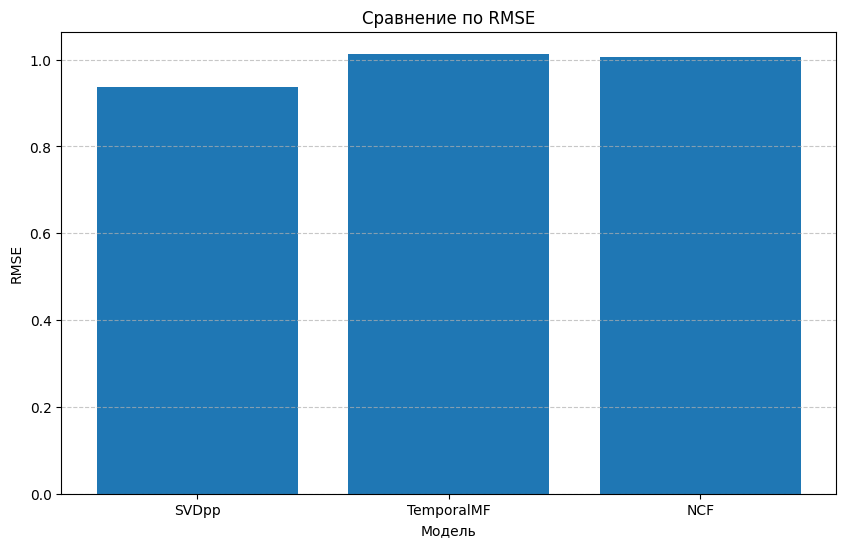

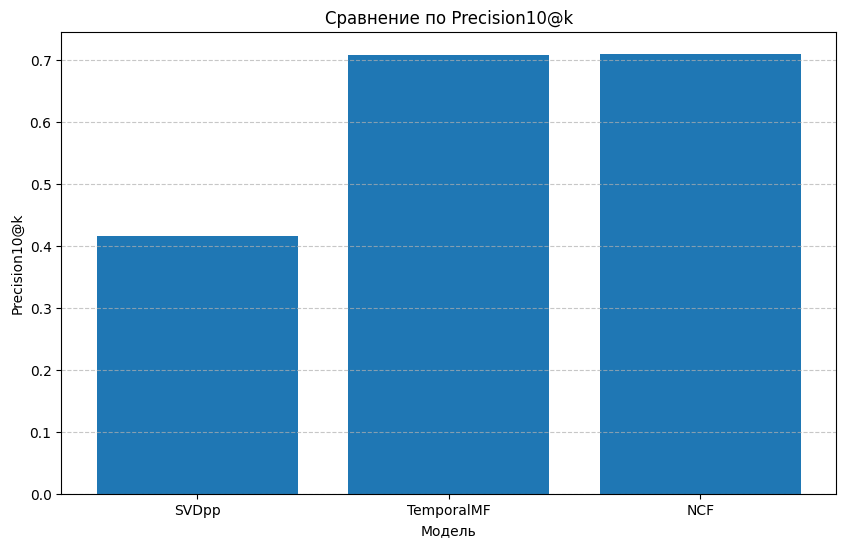

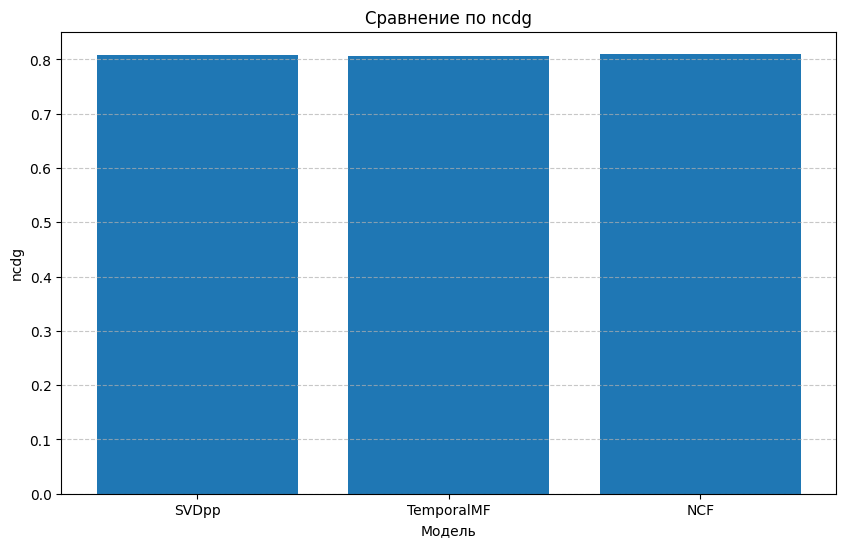

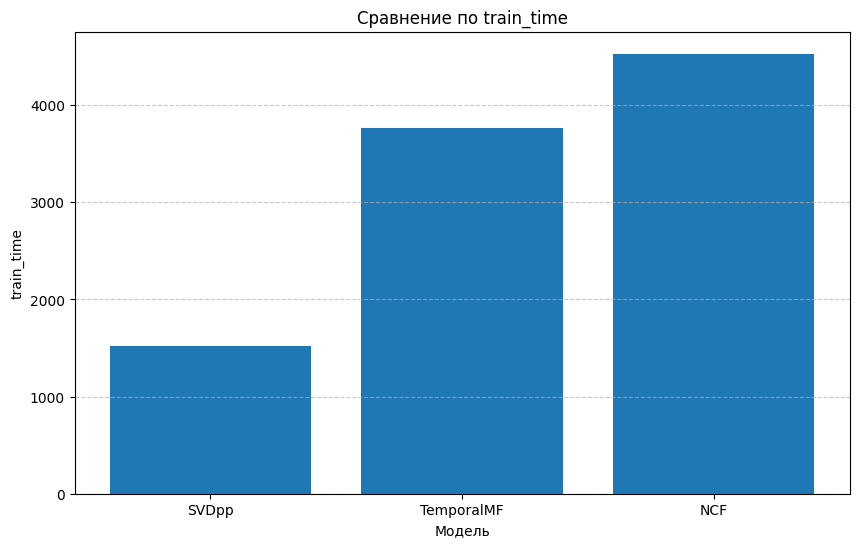

In [59]:
metrics = ['RMSE', 'Precision10@k', 'ncdg','train_time']
for metric in metrics:
    plt.figure(figsize=(10, 6))
    plt.bar(ispitaniya_results['Model'], ispitaniya_results[metric])
    plt.title(f'Сравнение по {metric}')
    plt.xlabel('Модель')
    plt.ylabel(metric)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

Сделаем предсказания для TemporalMF и NCF по одному и тому же Customer ID, чтоюы посмотреть как сильно отличаются рекомендации разных моделей друг от друга. Выбор этих моделей я сделал из-за высокого precision@10 по сравнению с SVDpp

In [73]:
customer_id = 1049643
if customer_id not in user2idx:
    raise ValueError(f"CustomerID {customer_id} не найден")
u_idx = user2idx[customer_id]
idx2movie = {idx: movie_id for movie_id, idx in movie2idx.items()}
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.eval()
u_tensor = torch.full((n_movies,), u_idx, dtype=torch.long, device=device)
m_tensor = torch.arange(n_movies, dtype=torch.long, device=device)
d_tensor = torch.zeros(n_movies, dtype=torch.float32, device=device)  
with torch.no_grad():
    preds_temporal = model(u_tensor, m_tensor, d_tensor).cpu().numpy()
model_1.eval() 
with torch.no_grad():
    preds_ncf = model_1(u_tensor, m_tensor, d_tensor).cpu().numpy()
results_final = pd.DataFrame({
    'MovieID': [idx2movie[i] for i in range(n_movies)],
    'TemporalMF': preds_temporal,
    'NCF': preds_ncf
})
user_actual = ratings_df[ratings_df['CustomerID'] == customer_id][['MovieID', 'Rating']]
user_actual = user_actual.rename(columns={'Rating': 'Actual'})
results_final = results_final.merge(user_actual, on='MovieID', how='left')
results_final = results_final.sort_values('TemporalMF', ascending=False)
print(results_final.head(20).to_string(index=False))

 MovieID  TemporalMF      NCF  Actual
    7230    4.007491 3.942333     NaN
    7057    3.917292 3.906932     NaN
    5515    3.861957 3.835821     5.0
    5258    3.854007 3.782381     NaN
    7569    3.844206 3.752061     NaN
    7751    3.836033 3.474071     NaN
    8191    3.834030 3.516281     NaN
    5103    3.829598 4.048436     NaN
    8832    3.795853 3.833832     5.0
    5549    3.785308 3.935693     5.0
    7302    3.784008 3.615958     NaN
    7393    3.768640 3.512053     NaN
    7424    3.767963 3.696340     5.0
    7833    3.767685 3.913349     NaN
    7577    3.762303 3.586472     NaN
    6739    3.748482 3.844290     5.0
    6807    3.747442 3.685522     5.0
    5092    3.746465 3.670155     NaN
    6007    3.743508 3.868170     NaN
    7110    3.738420 3.649817     NaN


In [75]:
rated_movie_ids_1049643 = set(
    ratings_df[ratings_df['CustomerID'] == user_id]['MovieID']
)

Посмотрим какие фильмы порекомендуют обе модели и сравним с теми, которые пользователь уже смотрел

In [114]:
user_id = 1049643
u_idx = user2idx[user_id]
idx2movie = {idx: mid for mid, idx in movie2idx.items()}
model.eval() 
with torch.no_grad():
    u_tensor = torch.full((n_movies,), u_idx, dtype=torch.long, device=device)
    m_tensor = torch.arange(n_movies, dtype=torch.long, device=device)
    d_tensor = torch.zeros(n_movies, dtype=torch.float32, device=device)
    preds_temporal = model(u_tensor, m_tensor, d_tensor).cpu().numpy()
rated_mask = np.array([
    idx2movie[i] in rated_movie_ids_1049643
    for i in range(n_movies)
])
preds_temporal[rated_mask] = -np.inf
top10_idx = np.argsort(preds_temporal)[::-1][:10]
top10_temporal = pd.DataFrame({
    'MovieID': [idx2movie[i] for i in top10_idx],
    'predicted_rating': preds_temporal[top10_idx]
})

# Если есть таблица фильмов с названиями
top10_temporal = top10_temporal.merge(movies_title, on='MovieID')
print("TemporalMF — Топ-10")
print(top10_temporal[['MovieID', 'Title', 'predicted_rating']])

TemporalMF — Топ-10
   MovieID                                              Title  \
0     7230  The Lord of the Rings: The Fellowship of the R...   
1     7057  Lord of the Rings: The Two Towers: Extended Ed...   
2     5258                               Ken Burns' Civil War   
3     7569                             Dead Like Me: Season 2   
4     7751                               Anne of Green Gables   
5     8191                                 Horatio Hornblower   
6     5103                             The Simpsons: Season 5   
7     7302  The Blue Planet: Seas of Life: Seasonal Seas -...   
8     7393                                    Prime Suspect 3   
9     7833                     Arrested Development: Season 2   

   predicted_rating  
0          4.007491  
1          3.917292  
2          3.854007  
3          3.844206  
4          3.836033  
5          3.834030  
6          3.829598  
7          3.784008  
8          3.768640  
9          3.767685  


In [115]:
watched_titles = movies_title[movies_title['MovieID'].isin(rated_movie_ids_1049643)]

print(watched_titles[['MovieID', 'Title']].head(10))

      MovieID                                Title
4414     4500        Les Dames du Bois de Boulogne
4420     4506               Breakfast at Tiffany's
4458     4545  Dances With Wolves: Special Edition
4471     4559                     Hearts and Minds
4547     4636                      Dressed to Kill
4551     4640                             Rain Man
4607     4697                Heat: Special Edition
4608     4698        The Lost World: Jurassic Park
4637     4727                 Apocalypse Now Redux
4680     4770                            The Trial


In [119]:
user_id = 1049643
u_idx = user2idx[user_id]
idx2movie = {idx: mid for mid, idx in movie2idx.items()}
model_1.eval() 
with torch.no_grad():
    u_tensor = torch.full((n_movies,), u_idx, dtype=torch.long, device=device)
    m_tensor = torch.arange(n_movies, dtype=torch.long, device=device)
    d_tensor = torch.zeros(n_movies, dtype=torch.float32, device=device)
    preds_ncf = model_1(u_tensor, m_tensor, d_tensor).cpu().numpy()
rated_mask = np.array([
    idx2movie[i] in rated_movie_ids_1049643
    for i in range(n_movies)
])
preds_ncf[rated_mask] = -np.inf
top10_idx = np.argsort(preds_ncf)[::-1][:10]
top10_ncf = pd.DataFrame({
    'MovieID': [idx2movie[i] for i in top10_idx],
    'predicted_rating': preds_ncf[top10_idx]
})

# Если есть таблица фильмов с названиями
top10_ncf = top10_ncf.merge(movies_title, on='MovieID')
print("NCF — Топ-10")
print(top10_ncf[['MovieID', 'Title', 'predicted_rating']])

NCF — Топ-10
   MovieID                                              Title  \
0     5103                             The Simpsons: Season 5   
1     7230  The Lord of the Rings: The Fellowship of the R...   
2     8535                             The Simpsons: Season 2   
3     7833                     Arrested Development: Season 2   
4     7057  Lord of the Rings: The Two Towers: Extended Ed...   
5     6450                                        City of God   
6     6007                     Arrested Development: Season 1   
7     4978                Freaks & Geeks: The Complete Series   
8     4877                                 Simpsons Gone Wild   
9     7430                           Six Feet Under: Season 1   

   predicted_rating  
0          4.048436  
1          3.942333  
2          3.925195  
3          3.913349  
4          3.906932  
5          3.894011  
6          3.868170  
7          3.864075  
8          3.856230  
9          3.844988  


Сделаем финанльный датафрейм с рекомендованными фильмами по двум моделям 

In [120]:
left = top10_temporal[['Title', 'predicted_rating']].rename(
    columns={'Title': 'TemporalMF_Title', 'predicted_rating': 'TemporalMF_Rating'}
).reset_index(drop=True)
right = top10_ncf[['Title', 'predicted_rating']].rename(
    columns={'Title': 'NCF_Title', 'predicted_rating': 'NCF_Rating'}
).reset_index(drop=True)
finalnie_results = pd.concat([left, right], axis=1)
print(finalnie_results)

                                    TemporalMF_Title  TemporalMF_Rating  \
0  The Lord of the Rings: The Fellowship of the R...           4.007491   
1  Lord of the Rings: The Two Towers: Extended Ed...           3.917292   
2                               Ken Burns' Civil War           3.854007   
3                             Dead Like Me: Season 2           3.844206   
4                               Anne of Green Gables           3.836033   
5                                 Horatio Hornblower           3.834030   
6                             The Simpsons: Season 5           3.829598   
7  The Blue Planet: Seas of Life: Seasonal Seas -...           3.784008   
8                                    Prime Suspect 3           3.768640   
9                     Arrested Development: Season 2           3.767685   

                                           NCF_Title  NCF_Rating  
0                             The Simpsons: Season 5    4.048436  
1  The Lord of the Rings: The Fellowship

Посмотрим сколько фильмов попало в пересение двух моделей 

In [121]:
combined_df = pd.merge(
    top10_temporal[['MovieID', 'Title']], 
    top10_ncf[['MovieID', 'Title']], 
    on='MovieID', 
    how='inner',
    suffixes=('_TemporalMF', '_NCF')
)

count_common = len(combined_df)
print(f"Количество фильмов в пересечении: {count_common}")
print(combined_df)

Количество фильмов в пересечении: 4
   MovieID                                   Title_TemporalMF  \
0     7230  The Lord of the Rings: The Fellowship of the R...   
1     7057  Lord of the Rings: The Two Towers: Extended Ed...   
2     5103                             The Simpsons: Season 5   
3     7833                     Arrested Development: Season 2   

                                           Title_NCF  
0  The Lord of the Rings: The Fellowship of the R...  
1  Lord of the Rings: The Two Towers: Extended Ed...  
2                             The Simpsons: Season 5  
3                     Arrested Development: Season 2  
